In [ ]:
from envs import actenv_jupyter, change_exp_dir, make_gpu_mem_reporter
actenv_jupyter(cuda_version="12.5", gcc_version="11", clear_cache=False)


[actenv_jupyter] CUDA_HOME=/usr/local/cuda-12.5
[actenv_jupyter] TORCH_CUDA_ARCH_LIST=8.0
[actenv_jupyter] CXX=/usr/bin/g++-11 | CC=/usr/bin/gcc-11
[actenv_jupyter] Ready.


{'CUDA_HOME': '/usr/local/cuda-12.5',
 'TORCH_CUDA_ARCH_LIST': '8.0',
 'CC': '/usr/bin/gcc-11',
 'CXX': '/usr/bin/g++-11',
 'CUDAHOSTCXX': '/usr/bin/g++-11',
 'CXXFLAGS': '-std=c++17',
 'PATH_head': '/usr/local/cuda-12.5/bin:/home/ids/yuhe/anaconda3/envs/styleGANenv/bin:/home/ids/yuhe/.vscode-server/cli/servers/Stable-c9d77990917f3102ada88be140d28b038d1dd7c7/server/bin/remote-cli',
 'LD_LIBRARY_PATH_head': '/usr/local/cuda-12.5/lib64:',
 'TORCH_CUDA_VERBOSE_BUILD': '1',
 'MAX_JOBS': '1'}

/tmp/ipykernel_1735161/595823340.py:5: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


Using random seed: 535
Selected indices: [576, 1715, 1600, 1656]


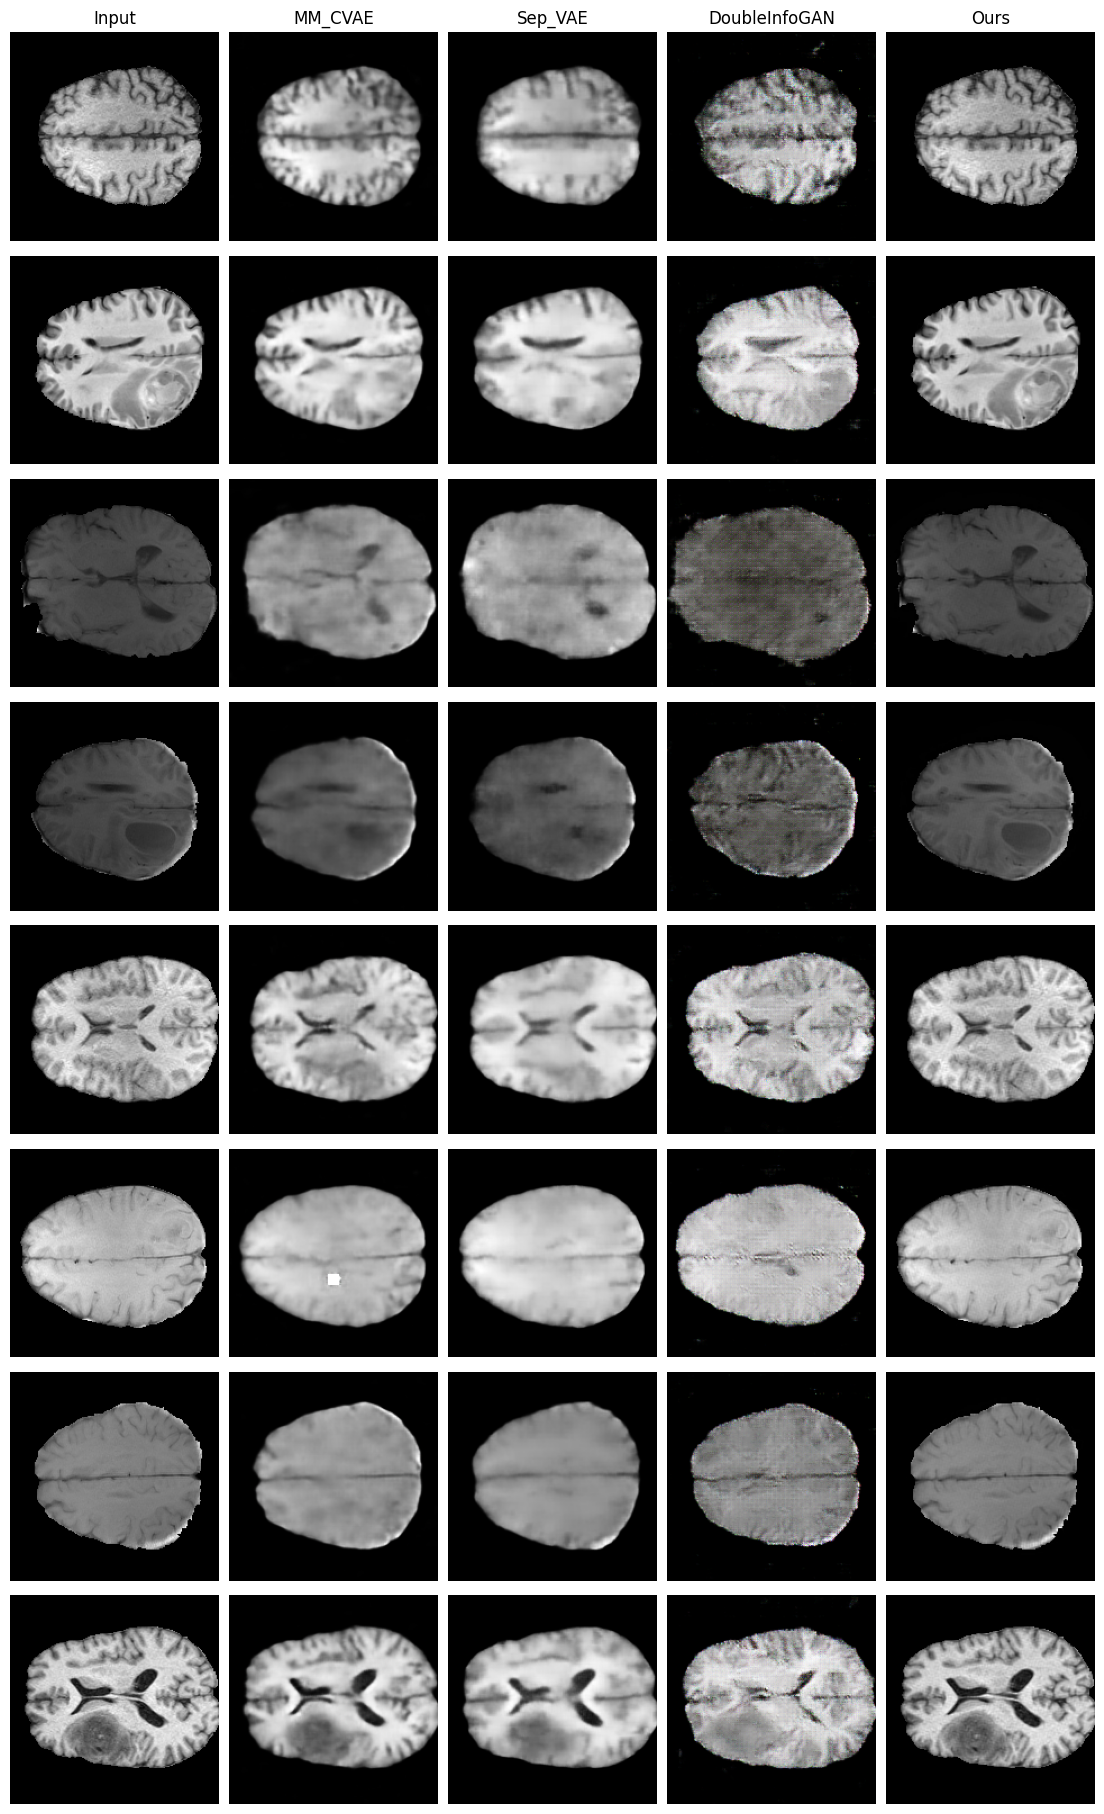

In [3]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from IPython.core.display import display, HTML

# Jupyter 显示优化
display(HTML("<style>.output_wrapper, .output {overflow-x: auto; max-width: 100% !important;}</style>"))

# =========================
# 参数
# =========================
dataset_name = "brats_ht_new"
root_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS"

crop_margin = 35   # ⭐ 每一边裁剪的像素数（上下左右）

# =========================
# 裁剪函数
# =========================
def crop_image(img, margin):
    if margin <= 0:
        return img
    w, h = img.size
    return img.crop((margin, margin, w - margin, h - margin))

# =========================
# 路径
# =========================
sota_dir_list_x = [
    f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Regularization/sorted_path/with_DR_RegrMI_90k/real_X",
    f"ca_baselines/{dataset_name}/mm_cvae/exp_001/recon_cs_X",
    f"ca_baselines/{dataset_name}/sep_vae/exp_001/recon_cs_X",
    f"ca_baselines/{dataset_name}/double_infogan_base/exp_002/recon_cs_X",
    f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Regularization/sorted_path/with_DR_RegrMI_90k/recon_f_X",
]

sota_dir_list_y = [
    f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Regularization/sorted_path/with_DR_RegrMI_90k/real_Y",
    f"ca_baselines/{dataset_name}/mm_cvae/exp_001/recon_cs_Y",
    f"ca_baselines/{dataset_name}/sep_vae/exp_001/recon_cs_Y",
    f"ca_baselines/{dataset_name}/double_infogan_base/exp_002/recon_cs_Y",
    f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Regularization/sorted_path/with_DR_RegrMI_90k/recon_f_Y",
]

title_list = [
    "Input",
    "MM_CVAE",
    "Sep_VAE",
    "DoubleInfoGAN",
    "Ours"
]

# =========================
# Step 1: 读取文件名
# =========================
folder_path = os.path.join(root_path, sota_dir_list_x[2])
all_filenames = sorted([
    f for f in os.listdir(folder_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

# =========================
# Step 2: 选择样本
# =========================
seed = random.randint(0, 20000)
print(f"Using random seed: {seed}")
random.seed(seed)
selected_indices = random.sample(range(len(all_filenames)), 4)
# selected_indices = [279, 1102, 1628]
print(f"Selected indices: {selected_indices}")

selected_filenames = [all_filenames[i] for i in selected_indices]

# =========================
# Step 3: 显示
# =========================
n_cols = len(title_list)
n_rows = 2 * len(selected_filenames)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(2.8 * n_cols, 5.8 * len(selected_filenames))
)

for i, filename in enumerate(selected_filenames):
    for j, (dir_x, dir_y, title) in enumerate(
        zip(sota_dir_list_x, sota_dir_list_y, title_list)
    ):
        # -------- X --------
        img_x_path = os.path.join(root_path, dir_x, filename)
        img_x = Image.open(img_x_path).convert("RGB")
        img_x = crop_image(img_x, crop_margin)

        axes[2 * i, j].imshow(img_x)
        axes[2 * i, j].axis("off")

        if i == 0:
            axes[2 * i, j].set_title(title, fontsize=12)

        if j == 0:
            axes[2 * i, j].set_ylabel(
                "X", fontsize=12, rotation=0, labelpad=20, va="center"
            )

        # -------- Y --------
        img_y_path = os.path.join(root_path, dir_y, filename)
        img_y = Image.open(img_y_path).convert("RGB")
        img_y = crop_image(img_y, crop_margin)

        axes[2 * i + 1, j].imshow(img_y)
        axes[2 * i + 1, j].axis("off")

        if j == 0:
            axes[2 * i + 1, j].set_ylabel(
                "Y", fontsize=12, rotation=0, labelpad=20, va="center"
            )

# 紧凑排版
plt.subplots_adjust(wspace=0.05, hspace=0.0)
plt.show()

# matches_x = {
#     0: '19.png',
#     1: '2343.png',
#     2: '968.png',
#     3: '2415.png',
#     4: '1261.png',
#     5: '44.png
#     6: '2422.png',
#     7: '2592.png'
# } 17015


/tmp/ipykernel_1735161/2616964686.py:5: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


Using random seed: 17444
Selected indices: [279, 1102, 1628]


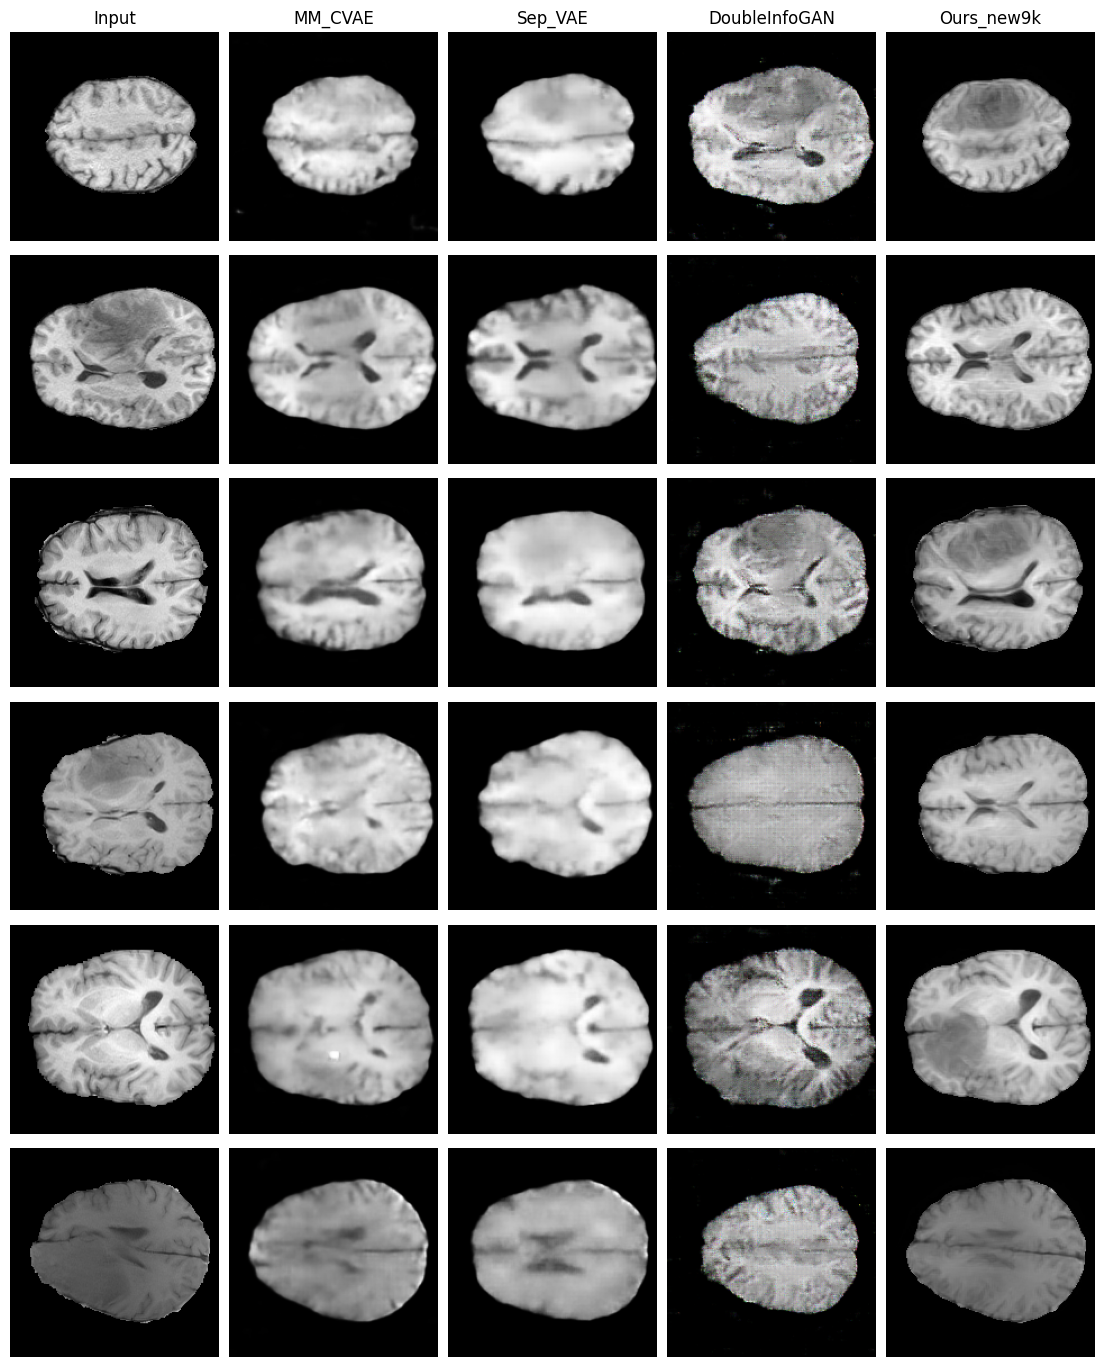

In [18]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from IPython.core.display import display, HTML

# Jupyter 显示优化
display(HTML("<style>.output_wrapper, .output {overflow-x: auto; max-width: 100% !important;}</style>"))

# =========================
# 参数设置
# =========================
dataset_name = "brats_ht_new"
root_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS"

crop_margin = 35   # ⭐ 每一边裁剪的像素数（上下左右）

# =========================
# 裁剪函数
# =========================
def crop_image(img, margin):
    if margin <= 0:
        return img
    w, h = img.size
    return img.crop((margin, margin, w - margin, h - margin))

# =========================
# 路径设置
# =========================
sota_dir_list_x = [
    f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Regularization/sorted_path/with_DR_RegrMI_90k/real_X",
    f"ca_baselines/{dataset_name}/mm_cvae/exp_001/swap_X2Y",
    f"ca_baselines/{dataset_name}/sep_vae/exp_001/swap_X2Y",
    f"ca_baselines/{dataset_name}/double_infogan_base/exp_002/swap_X2Y",
    f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Regularization/sorted_path/with_DR_RegrMI_90k/swap_f_X2Y"
]

sota_dir_list_y = [
    f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Regularization/sorted_path/with_DR_RegrMI_90k/real_Y",
    f"ca_baselines/{dataset_name}/mm_cvae/exp_001/swap_Y2X",
    f"ca_baselines/{dataset_name}/sep_vae/exp_001/swap_Y2X",
    f"ca_baselines/{dataset_name}/double_infogan_base/exp_002/swap_Y2X",
    f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Regularization/sorted_path/with_DR_RegrMI_90k/swap_f_Y2X"

]

title_list = [
    "Input",
    "MM_CVAE",
    "Sep_VAE",
    "DoubleInfoGAN",
    "Ours_new9k"
]

# =========================
# Step 1: 读取文件名
# =========================
folder_path = os.path.join(root_path, sota_dir_list_x[2])
all_filenames = sorted([
    f for f in os.listdir(folder_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

# =========================
# Step 2: 选择样本
# =========================
seed = random.randint(0, 20000)
print(f"Using random seed: {seed}")
random.seed(seed)
selected_indices = random.sample(range(len(all_filenames)), 4)
selected_indices = [279, 1102, 1628]
print(f"Selected indices: {selected_indices}")

selected_filenames = [all_filenames[i] for i in selected_indices]

# =========================
# Step 3: 画图
# =========================
n_cols = len(title_list)
n_rows = 2 * len(selected_filenames)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(2.8 * n_cols, 5.8 * len(selected_filenames))
)

for i, filename in enumerate(selected_filenames):
    for j, (dir_x, dir_y, title) in enumerate(
        zip(sota_dir_list_x, sota_dir_list_y, title_list)
    ):
        # ---------- X ----------
        img_x_path = os.path.join(root_path, dir_x, filename)
        img_x = Image.open(img_x_path).convert("RGB")
        img_x = crop_image(img_x, crop_margin)

        axes[2 * i, j].imshow(img_x)
        axes[2 * i, j].axis("off")

        if i == 0:
            axes[2 * i, j].set_title(title, fontsize=12)

        if j == 0:
            axes[2 * i, j].set_ylabel(
                "X", fontsize=12, rotation=0, labelpad=20, va="center"
            )

        # ---------- Y ----------
        img_y_path = os.path.join(root_path, dir_y, filename)
        img_y = Image.open(img_y_path).convert("RGB")
        img_y = crop_image(img_y, crop_margin)

        axes[2 * i + 1, j].imshow(img_y)
        axes[2 * i + 1, j].axis("off")

        if j == 0:
            axes[2 * i + 1, j].set_ylabel(
                "Y", fontsize=12, rotation=0, labelpad=20, va="center"
            )

# 紧凑排版
plt.subplots_adjust(wspace=0.05, hspace=0.0)
plt.show()

# matches_x = {
#     0: '19.png',
#     1: '2343.png',
#     2: '968.png',
#     3: '2415.png',
#     4: '1261.png',
#     5: '44.png
#     6: '2422.png',
#     7: '2592.png'
# }[62, 1524, 890, 5]  [667, 452, 1126, 279]  [717, 1860, 432, 633]  [63, 1102, 1842, 128]
# [1898, 149, 1588, 580]    [563, 1477, 1182, 1628]  [756, 646, 1620, 1395]  [758, 791, 1752, 557]
 #[20, 207, 1278, 68]   b
 # 
 # 279  1102 1628

/tmp/ipykernel_1149338/1654977337.py:5: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


Using random seed: 821
Selected indices: [2013, 1246, 1479, 944]


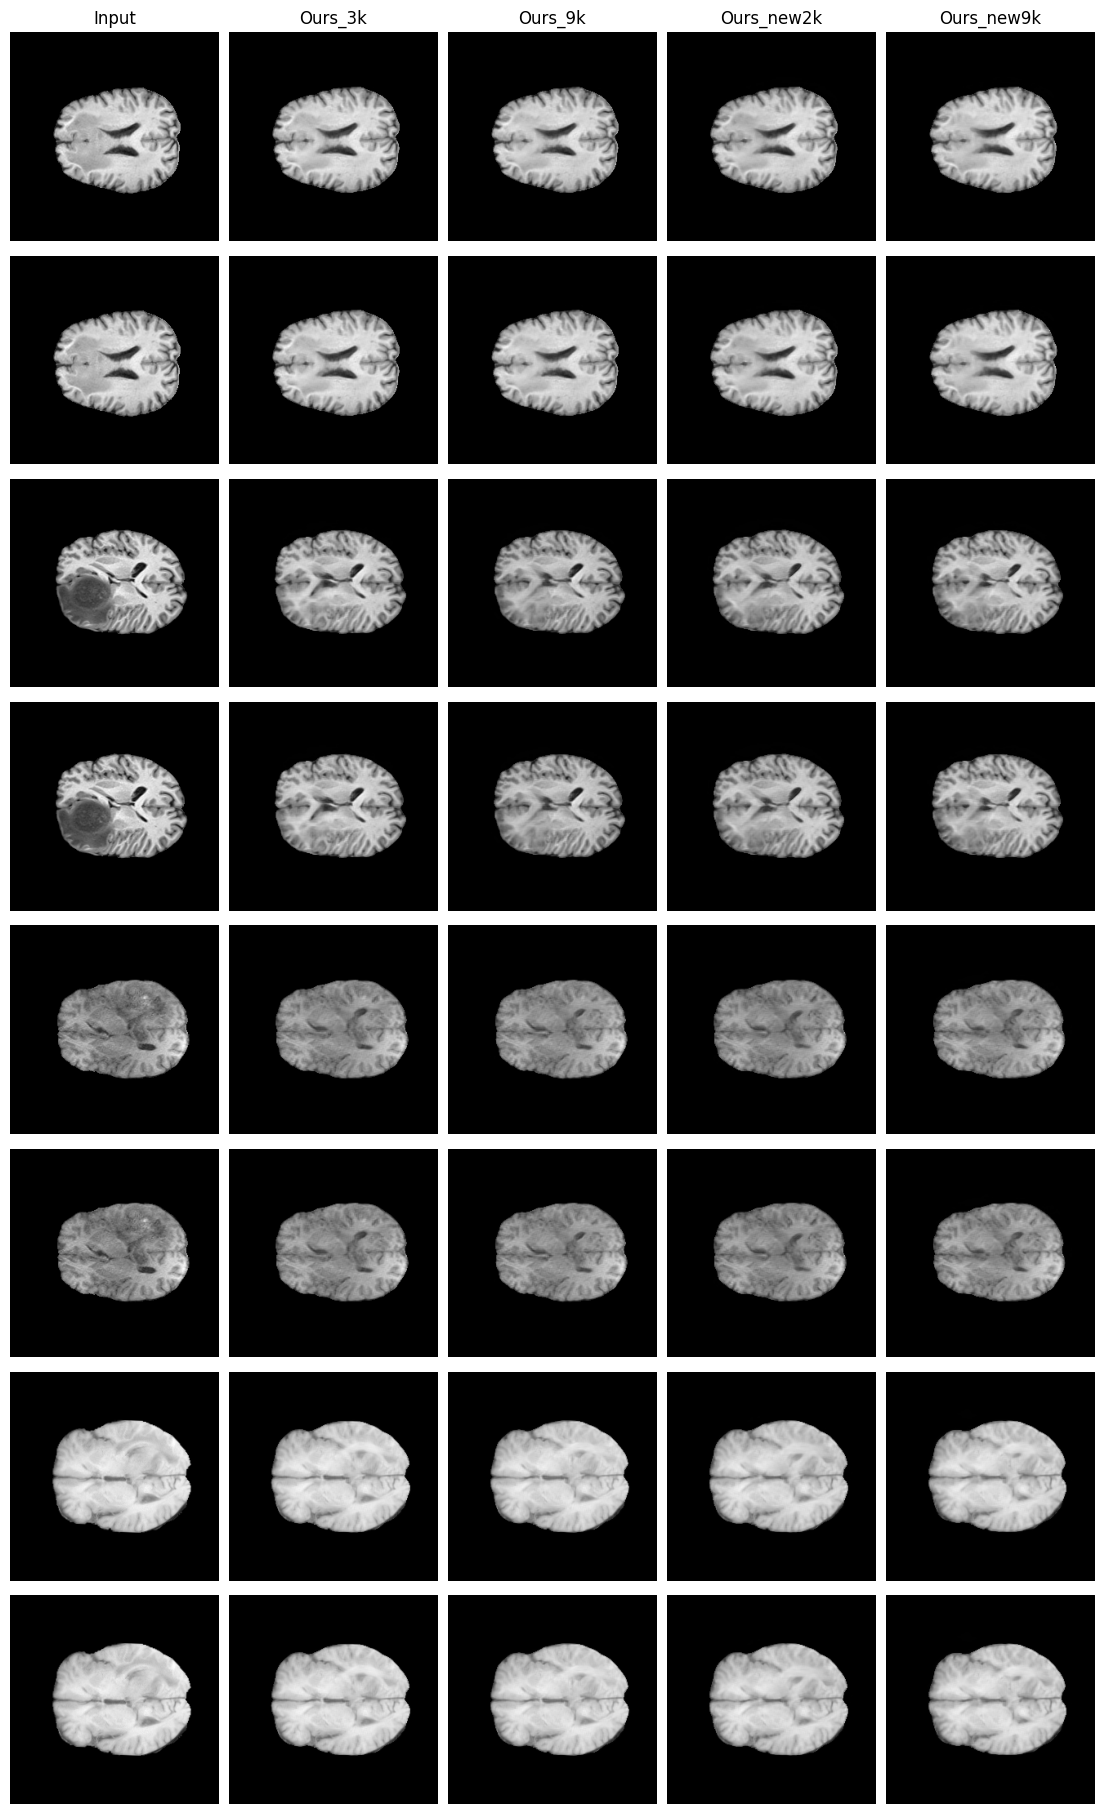

In [10]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from IPython.core.display import display, HTML
display(HTML("<style>.output_wrapper, .output {overflow-x: auto; max-width: 100% !important;}</style>"))


dataset_name = "brats_ht_new"

# Parameters
root_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS"
# ours_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/ca_baseline"

sota_dir_list_x = [
    f"Ours_brats_images/brats_ht_new_2k/images/{dataset_name}/real_Y",

    # f"ca_baselines/{dataset_name}/mm_cvae/exp_001/swap_Y2X",
    # f"ca_baselines/{dataset_name}/sep_vae/exp_001/swap_Y2X",
    # f"ca_baselines/{dataset_name}/double_infogan_base/exp_002/swap_Y2X",
    # "ours_brats/brats_ht/brats_ht_3k/images/brats_ht/swap_w_X2Y",
    f"Ours_brats_images/brats_ht_3k/images/{dataset_name}/swap_f_Y2X",
    f"Ours_brats_images/brats_ht_9k/images/{dataset_name}/swap_f_Y2X",
    f"Ours_brats_images/brats_ht_new_2k/images/{dataset_name}/swap_f_Y2X",
    f"Ours_brats_images/brats_ht_new_9k/images/{dataset_name}/swap_f_Y2X"

]
#  brats_ht_3k    brats_ht_9k    brats_ht_new_2k    brats_ht_new_9k

sota_dir_list_y = [
    f"Ours_brats_images/brats_ht_new_2k/images/{dataset_name}/real_Y",

    # f"ca_baselines/{dataset_name}/mm_cvae/exp_001/swap_Y2X",
    # f"ca_baselines/{dataset_name}/sep_vae/exp_001/swap_Y2X",
    # f"ca_baselines/{dataset_name}/double_infogan_base/exp_002/swap_Y2X",
    # "ours_brats/brats_ht/brats_ht_3k/images/brats_ht/swap_w_X2Y",
    f"Ours_brats_images/brats_ht_3k/images/{dataset_name}/swap_f_Y2X",
    f"Ours_brats_images/brats_ht_9k/images/{dataset_name}/swap_f_Y2X",
    f"Ours_brats_images/brats_ht_new_2k/images/{dataset_name}/swap_f_Y2X",
    f"Ours_brats_images/brats_ht_new_9k/images/{dataset_name}/swap_f_Y2X"

]

title_list = [
    "Input",

    "Ours_3k",
    "Ours_9k",
    "Ours_new2k",
    "Ours_new9k"
]

# Step 1: Get filenames from one folder (assumed aligned)
folder_path = os.path.join(root_path, sota_dir_list_x[2])
all_filenames = sorted([f for f in os.listdir(folder_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))])

# Step 2: Select random indices
seed = random.randint(0, 20000)
print(f"Using random seed: {seed}")
random.seed(seed)
selected_indices = random.sample(range(len(all_filenames)), 4)
# selected_indices = [279,1102,1628] 
print(f"Selected indices: {selected_indices}")
selected_filenames = [all_filenames[i] for i in selected_indices]

# Step 3: Display in 2 rows per example (X on top, Y below)
n_cols = len(title_list)
n_rows = 2 * len(selected_filenames)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2.8 * n_cols, 5.8 * len(selected_filenames)))

for i, filename in enumerate(selected_filenames):
    for j, (dir_x, dir_y, title) in enumerate(zip(sota_dir_list_x, sota_dir_list_y, title_list)):
        # Top row: X
        img_x_path = os.path.join(root_path, dir_x, filename)
        img_x = Image.open(img_x_path).convert("RGB")
        axes[2 * i, j].imshow(img_x)
        axes[2 * i, j].axis("off")
        if i == 0:
            axes[2 * i, j].set_title(title, fontsize=12)
        if j == 0:
            axes[2 * i, j].set_ylabel("X", fontsize=12, rotation=0, labelpad=20, va='center')

        # Bottom row: Y
        img_y_path = os.path.join(root_path, dir_y, filename)
        img_y = Image.open(img_y_path).convert("RGB")
        axes[2 * i + 1, j].imshow(img_y)
        axes[2 * i + 1, j].axis("off")
        if j == 0:
            axes[2 * i + 1, j].set_ylabel("Y", fontsize=12, rotation=0, labelpad=20, va='center')

# Tighter spacing
plt.subplots_adjust(wspace=0.05, hspace=0.0)
plt.show()
# matches_x = {
#     0: '19.png',
#     1: '2343.png',
#     2: '968.png',
#     3: '2415.png',
#     4: '1261.png',
#     5: '44.png
#     6: '2422.png',
#     7: '2592.png'
# }[62, 1524, 890, 5]  [667, 452, 1126, 279]  [717, 1860, 432, 633]  [63, 1102, 1842, 128]
# [1898, 149, 1588, 580]    [563, 1477, 1182, 1628]  [756, 646, 1620, 1395]  [758, 791, 1752, 557]
 #[20, 207, 1278, 68]   
 # 
 # 279  1102 1628

# compare to diffusion models

# Diffusion models results

In [3]:
114*4+3

459

/tmp/ipykernel_798854/324740835.py:5: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


Total images: 2080
Example filenames: ['0.png', '1.png', '2.png', '3.png', '4.png']
Selected filenames: ['459.png']


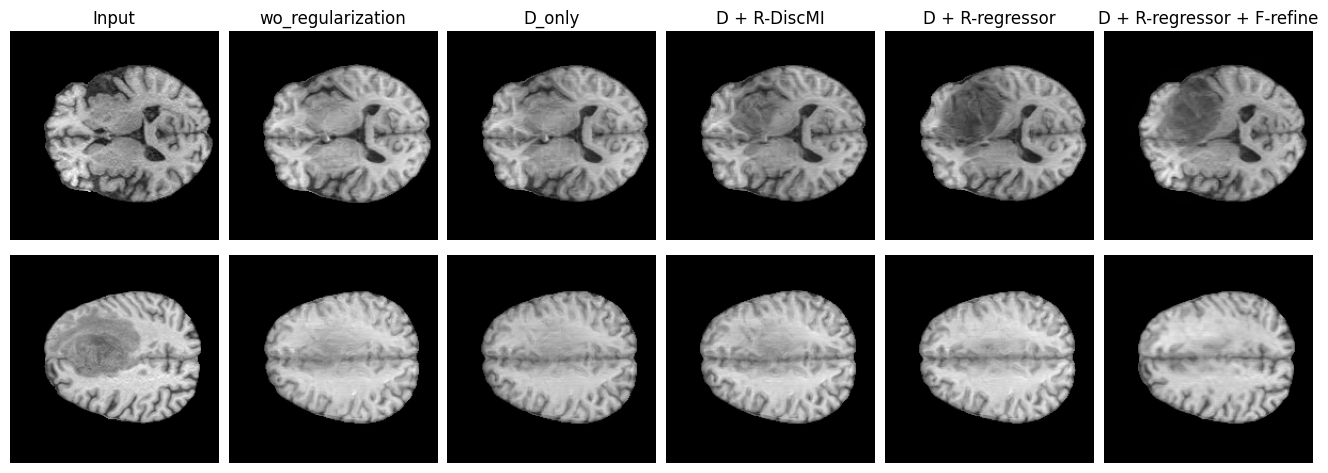

In [4]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from IPython.core.display import display, HTML

# Jupyter 显示优化
display(HTML("<style>.output_wrapper, .output {overflow-x: auto; max-width: 100% !important;}</style>"))

# =========================
# 参数设置
# =========================
dataset_name = "brats_ht_new"
root_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Regularization/unsorted_path"

crop_margin = 30   # 每一边裁剪的像素数

# =========================
# 裁剪函数
# =========================
def crop_image(img, margin):
    if margin <= 0:
        return img
    w, h = img.size
    return img.crop((margin, margin, w - margin, h - margin))

# =========================
# 路径设置
# =========================
sota_dir_list_x = [
    "with_DR_RegrMI_90k/real_X",
    "wo_regular/swap_w_X2Y",
    "with_D_only/swap_w_X2Y",
    "with_DR_DiscMI/swap_w_X2Y",
    "with_DR_RegrMI_90k/swap_w_X2Y",
    "with_DR_RegrMI_90k/swap_f_X2Y",
]

sota_dir_list_y = [
    "with_DR_RegrMI_90k/real_Y",
    "wo_regular/swap_w_Y2X",
    "with_D_only/swap_w_Y2X",
    "with_DR_DiscMI/swap_w_Y2X",
    "with_DR_RegrMI_90k/swap_w_Y2X",
    "with_DR_RegrMI_90k/swap_f_Y2X",
]

title_list = [
    "Input",
    "wo_regularization",
    "D_only",
    "D + R-DiscMI",
    "D + R-regressor",
    "D + R-regressor + F-refine"
]

# =========================
# Step 1: 读取并排序文件名（⭐关键）
# =========================
folder_path = os.path.join(root_path, sota_dir_list_x[2])

all_filenames = sorted(
    [f for f in os.listdir(folder_path)
     if f.lower().endswith((".png", ".jpg", ".jpeg"))],
    key=lambda x: int(os.path.splitext(x)[0])  # 关键：按数字排序
)

print(f"Total images: {len(all_filenames)}")
print("Example filenames:", all_filenames[:5])

# =========================
# Step 2: 选择样本
# =========================
selected_indices = [459]
selected_filenames = [all_filenames[i] for i in selected_indices]

print("Selected filenames:", selected_filenames)
# 👉 这里应当看到 ['459.png']

# =========================
# Step 3: 画图
# =========================
n_cols = len(title_list)
n_rows = 2 * len(selected_filenames)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(2.8 * n_cols, 5.8 * len(selected_filenames))
)

for i, filename in enumerate(selected_filenames):
    for j, (dir_x, dir_y, title) in enumerate(
        zip(sota_dir_list_x, sota_dir_list_y, title_list)
    ):
        # ---------- X ----------
        img_x_path = os.path.join(root_path, dir_x, filename)
        img_x = Image.open(img_x_path).convert("RGB")
        img_x = crop_image(img_x, crop_margin)

        axes[2 * i, j].imshow(img_x)
        axes[2 * i, j].axis("off")

        if i == 0:
            axes[2 * i, j].set_title(title, fontsize=12)

        if j == 0:
            axes[2 * i, j].set_ylabel(
                "X", fontsize=12, rotation=0, labelpad=20, va="center"
            )

        # ---------- Y ----------
        img_y_path = os.path.join(root_path, dir_y, filename)
        img_y = Image.open(img_y_path).convert("RGB")
        img_y = crop_image(img_y, crop_margin)

        axes[2 * i + 1, j].imshow(img_y)
        axes[2 * i + 1, j].axis("off")

        if j == 0:
            axes[2 * i + 1, j].set_ylabel(
                "Y", fontsize=12, rotation=0, labelpad=20, va="center"
            )

plt.subplots_adjust(wspace=0.05, hspace=0.0)
plt.show()
